In [1]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from sklearn.manifold import TSNE
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from scipy.stats import kurtosis, skew
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from scipy.spatial.distance import cdist

In [2]:
data_path = "../saved_models/STCRL_transfer_learning/embeddings/embedded_trajectories.csv"
df = pd.read_csv(data_path)
df_human = pd.read_csv("../Dataset/Scores/human_scores.csv")

In [3]:
# df_human.columns
df_human = df_human[['exploration_score', 'exploitation_score',
       'exploration_exploitation_ratio']]
df_human

,exploration_score,exploitation_score,exploration_exploitation_ratio
0,0.048183,0.000000,4.818315
1,0.233841,0.170576,1.294971
2,0.123192,0.280172,0.424550
3,0.100758,0.321796,0.303676
4,0.091640,0.342180,0.260208
...,...,...,...
16315,0.014563,0.491053,0.029065
16316,0.013197,0.201343,0.062444
16317,0.023016,0.413976,0.054287
16318,0.051534,0.360152,0.139224


In [5]:
merged_df = pd.merge(df, df_human, left_index=True, right_index=True)
merged_df.columns

Index(['participant_id', 'session_no', 'task_type', 'trial_no', 'day', 'block',
       'start_point_x', 'start_point_y', 'target_point_x', 'target_point_y',
       'start_time', 'end_time', 'quadrant', 'is_success', 'actual_dist',
       'movement_dist', 'completion_time', 'path', 'time_string',
       'time_diff_ms', 'Age', 'Cohort', 'Gestational_Age',
       'mabc_total_test_score', 'mabc_standard_score', 'mabc_percentile',
       'distances', 'rmsd', 'normalized_trajectory',
       'trajectory_embedding_completion_time',
       'trajectory_embedding_task_type', 'trajectory_embedding_rmsd',
       'trajectory_embedding_success',
       'trajectory_embedding_within_between_subject',
       'trajectory_embedding_multi_loss', 'exploration_score',
       'exploitation_score', 'exploration_exploitation_ratio'],
      dtype='object')

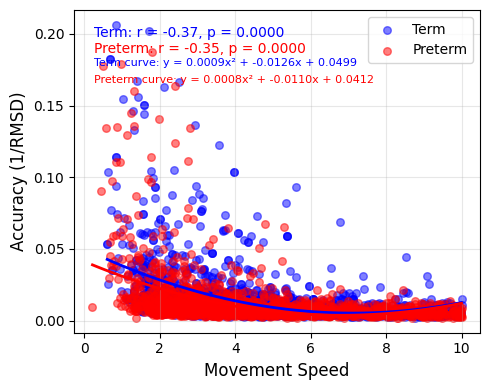

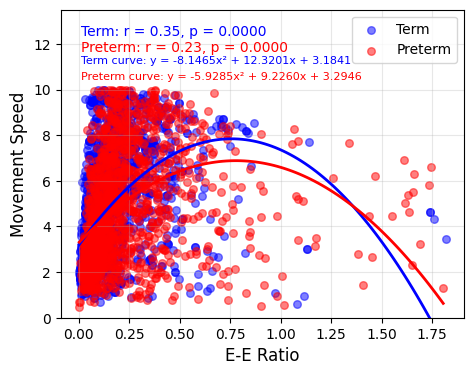

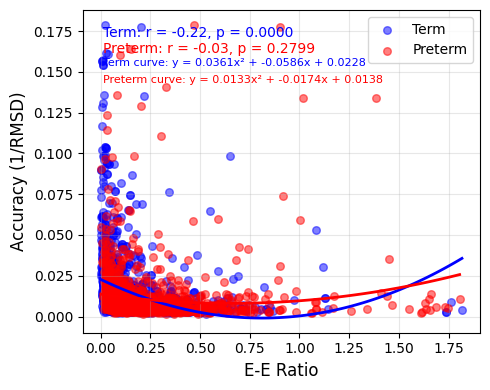

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from scipy import stats
from sklearn.utils import resample

def analyze_speed_accuracy_tradeoff(df):
    """
    Create a plot analyzing speed-accuracy trade-offs between Term and Preterm groups,
    using sampling to balance the groups. Removes samples with speed <= 10.
    Fits polynomial curves instead of linear regression lines.
    
    Parameters:
    -----------
    df : pandas.DataFrame
        DataFrame with performance data and Cohort information
    
    Returns:
    --------
    matplotlib.figure.Figure
        The generated figure
    """
    # Make a copy of the dataframe and ensure all needed columns are numeric
    df = df.copy()
    # Remove outliers
    df = df[df['completion_time'] <= 10]
    # Ensure numerical data types for relevant columns
    numeric_cols = ['movement_dist', 'completion_time', 'rmsd']
    for col in numeric_cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')
    
    # Calculate performance metrics
    df['movement_speed'] = df['completion_time']  # As provided in code
    df['accuracy'] = 1/df['rmsd']
    
    # Replace infinites with NaN and drop NaN values
    df = df.replace([np.inf, -np.inf], np.nan)
    df = df.dropna(subset=['movement_speed', 'accuracy', 'Cohort'])
    
   
    
    # Remove outliers (values beyond 3 standard deviations from the mean)
    for metric in ['movement_speed', 'accuracy']:
        mean = df[metric].mean()
        std = df[metric].std()
        df = df[(df[metric] >= mean - 3*std) & (df[metric] <= mean + 3*std)]
    
    # Split data by cohort
    term_data = df[df['Cohort'] == 'Term']
    preterm_data = df[df['Cohort'] == 'Preterm']
    
    # Apply sampling to balance the groups
    min_samples = min(len(term_data), len(preterm_data))
    
    if len(term_data) > min_samples:
        term_data = resample(term_data, n_samples=min_samples, random_state=42)
    if len(preterm_data) > min_samples:
        preterm_data = resample(preterm_data, n_samples=min_samples, random_state=42)
    
    # Create figure
    fig, ax = plt.subplots(figsize=(5, 4))
    
    # Scatter plot for each group
    ax.scatter(term_data['movement_speed'], term_data['accuracy'], 
               color='blue', alpha=0.5, s=30, label='Term')
    ax.scatter(preterm_data['movement_speed'], preterm_data['accuracy'], 
               color='red', alpha=0.5, s=30, label='Preterm')
    
    # Function to fit and plot polynomial curve
    def fit_and_plot_poly_curve(x, y, color, ax):
        # Sort x values for smooth curve
        idx = np.argsort(x)
        x_sorted = np.array(x.iloc[idx])
        y_sorted = np.array(y.iloc[idx])
        
        # Fit polynomial degree 2 (quadratic)
        coeffs = np.polyfit(x_sorted, y_sorted, 2)
        
        # Create points for smooth curve
        x_curve = np.linspace(min(x_sorted), max(x_sorted), 100)
        y_curve = np.polyval(coeffs, x_curve)
        
        # Plot the curve
        ax.plot(x_curve, y_curve, color=color, linewidth=2)
        
        return coeffs
    
    # Fit polynomial curves for each group
    term_coeffs = fit_and_plot_poly_curve(term_data['movement_speed'], term_data['accuracy'], 'blue', ax)
    preterm_coeffs = fit_and_plot_poly_curve(preterm_data['movement_speed'], preterm_data['accuracy'], 'red', ax)
    
    # Calculate and add correlation statistics for each group
    r_term, p_term = stats.pearsonr(term_data['movement_speed'], term_data['accuracy'])
    r_preterm, p_preterm = stats.pearsonr(preterm_data['movement_speed'], preterm_data['accuracy'])
    
    # Add statistics to plot
    ax.text(0.05, 0.95, f'Term: r = {r_term:.2f}, p = {p_term:.4f}', 
            transform=ax.transAxes, fontsize=10, va='top', color='blue')
    ax.text(0.05, 0.90, f'Preterm: r = {r_preterm:.2f}, p = {p_preterm:.4f}', 
            transform=ax.transAxes, fontsize=10, va='top', color='red')
    
    # Add polynomial equations
    term_eq = f"y = {term_coeffs[0]:.4f}x² + {term_coeffs[1]:.4f}x + {term_coeffs[2]:.4f}"
    preterm_eq = f"y = {preterm_coeffs[0]:.4f}x² + {preterm_coeffs[1]:.4f}x + {preterm_coeffs[2]:.4f}"
    
    ax.text(0.05, 0.85, f'Term curve: {term_eq}', 
            transform=ax.transAxes, fontsize=8, va='top', color='blue')
    ax.text(0.05, 0.80, f'Preterm curve: {preterm_eq}', 
            transform=ax.transAxes, fontsize=8, va='top', color='red')
    
    # Add labels
    ax.set_xlabel('Movement Speed', fontsize=12)
    ax.set_ylabel('Accuracy (1/RMSD)', fontsize=12)
    ax.grid(True, alpha=0.3)
    ax.legend()
    
    plt.tight_layout()
    
    return fig


def analyze_ratio_vs_performance(df):
    """
    Create two plots analyzing:
    1. Speed vs exploration_exploitation_ratio for Term and Preterm
    2. Accuracy vs exploration_exploitation_ratio for Term and Preterm
    Removes samples with speed <= 10 and fits polynomial curves.
    
    Parameters:
    -----------
    df : pandas.DataFrame
        DataFrame with performance, exploration/exploitation data, and Cohort information
    
    Returns:
    --------
    tuple
        (speed_figure, accuracy_figure)
    """
    # Make a copy of the dataframe and ensure all needed columns are numeric
    df = df.copy()
    df = df[~((df['session_no'] == 1) & (df['trial_no'].isin([1, 2, 3])))]
    df = df[df['completion_time'] <= 10]
    
    # Ensure numerical data types for relevant columns
    numeric_cols = ['movement_dist', 'completion_time', 'rmsd', 
                   'exploration_score', 'exploitation_score', 'exploration_exploitation_ratio']
    
    for col in numeric_cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')
    
    # Calculate performance metrics if they don't exist
    if 'movement_speed' not in df.columns:
        df['movement_speed'] = df['completion_time']  # As provided in code
    if 'accuracy' not in df.columns:
        df['accuracy'] = 1/df['rmsd']
    
    # Replace infinites with NaN and drop NaN values
    df = df.replace([np.inf, -np.inf], np.nan)
    df = df.dropna(subset=['movement_speed', 'accuracy', 'exploration_exploitation_ratio', 'Cohort'])
    
    # Remove samples with speed > 10
    
    
    # Remove outliers (values beyond 3 standard deviations from the mean)
    for metric in ['movement_speed', 'accuracy', 'exploration_exploitation_ratio']:
        mean = df[metric].mean()
        std = df[metric].std()
        df = df[(df[metric] >= mean - 3*std) & (df[metric] <= mean + 3*std)]
    
    # Split data by cohort
    term_data = df[df['Cohort'] == 'Term']
    preterm_data = df[df['Cohort'] == 'Preterm']
    
    # Apply sampling to balance the groups if needed
    min_samples = min(len(term_data), len(preterm_data))
    
    if len(term_data) > min_samples:
        term_data_sampled = resample(term_data, n_samples=min_samples, random_state=42)
    else:
        term_data_sampled = term_data.copy()
        
    if len(preterm_data) > min_samples:
        preterm_data_sampled = resample(preterm_data, n_samples=min_samples, random_state=42)
    else:
        preterm_data_sampled = preterm_data.copy()
    
    # Function to fit and plot polynomial curve
    def fit_and_plot_poly_curve(x, y, color, ax):
        # Sort x values for smooth curve
        idx = np.argsort(x)
        x_sorted = np.array(x.iloc[idx])
        y_sorted = np.array(y.iloc[idx])
        
        # Fit polynomial degree 2 (quadratic)
        coeffs = np.polyfit(x_sorted, y_sorted, 2)
        
        # Create points for smooth curve
        x_curve = np.linspace(min(x_sorted), max(x_sorted), 100)
        y_curve = np.polyval(coeffs, x_curve)
        
        # Plot the curve
        ax.plot(x_curve, y_curve, color=color, linewidth=2)
        
        return coeffs
    
    # 1. Create figure for Speed vs E-E Ratio
    speed_fig, speed_ax = plt.subplots(figsize=(5.2, 4))
    
    # Scatter plot for each group
    speed_ax.scatter(term_data_sampled['exploration_exploitation_ratio'], term_data_sampled['movement_speed'], 
                     color='blue', alpha=0.5, s=30, label='Term')
    speed_ax.scatter(preterm_data_sampled['exploration_exploitation_ratio'], preterm_data_sampled['movement_speed'], 
                     color='red', alpha=0.5, s=30, label='Preterm')
    
    # Fit polynomial curves for each group
    term_coeffs = fit_and_plot_poly_curve(term_data_sampled['exploration_exploitation_ratio'], 
                                         term_data_sampled['movement_speed'], 'blue', speed_ax)
    preterm_coeffs = fit_and_plot_poly_curve(preterm_data_sampled['exploration_exploitation_ratio'], 
                                            preterm_data_sampled['movement_speed'], 'red', speed_ax)
    
    # Calculate correlation statistics
    r_term_speed, p_term_speed = stats.pearsonr(term_data_sampled['exploration_exploitation_ratio'], 
                                                term_data_sampled['movement_speed'])
    r_preterm_speed, p_preterm_speed = stats.pearsonr(preterm_data_sampled['exploration_exploitation_ratio'], 
                                                     preterm_data_sampled['movement_speed'])
    
    # Add statistics to plot
    speed_ax.text(0.05, 0.95, f'Term: r = {r_term_speed:.2f}, p = {p_term_speed:.4f}', 
                  transform=speed_ax.transAxes, fontsize=10, va='top', color='blue')
    speed_ax.text(0.05, 0.90, f'Preterm: r = {r_preterm_speed:.2f}, p = {p_preterm_speed:.4f}', 
                  transform=speed_ax.transAxes, fontsize=10, va='top', color='red')
    
    # Add polynomial equations
    term_eq = f"y = {term_coeffs[0]:.4f}x² + {term_coeffs[1]:.4f}x + {term_coeffs[2]:.4f}"
    preterm_eq = f"y = {preterm_coeffs[0]:.4f}x² + {preterm_coeffs[1]:.4f}x + {preterm_coeffs[2]:.4f}"
    
    speed_ax.text(0.05, 0.85, f'Term curve: {term_eq}', 
                  transform=speed_ax.transAxes, fontsize=8, va='top', color='blue')
    speed_ax.text(0.05, 0.80, f'Preterm curve: {preterm_eq}', 
                  transform=speed_ax.transAxes, fontsize=8, va='top', color='red')
    
    # Add labels
    speed_ax.set_xlabel('E-E Ratio', fontsize=12)
    speed_ax.set_ylabel('Movement Speed', fontsize=12)
    speed_ax.grid(True, alpha=0.3)
    speed_ax.legend()
    speed_ax.set_ylim(0,13.5)
    
    # 2. Create figure for Accuracy vs E-E Ratio
    acc_fig, acc_ax = plt.subplots(figsize=(5, 4))
    
    # Scatter plot for each group
    acc_ax.scatter(term_data_sampled['exploration_exploitation_ratio'], term_data_sampled['accuracy'], 
                   color='blue', alpha=0.5, s=30, label='Term')
    acc_ax.scatter(preterm_data_sampled['exploration_exploitation_ratio'], preterm_data_sampled['accuracy'], 
                   color='red', alpha=0.5, s=30, label='Preterm')
    
    # Fit polynomial curves for each group
    term_acc_coeffs = fit_and_plot_poly_curve(term_data_sampled['exploration_exploitation_ratio'], 
                                            term_data_sampled['accuracy'], 'blue', acc_ax)
    preterm_acc_coeffs = fit_and_plot_poly_curve(preterm_data_sampled['exploration_exploitation_ratio'], 
                                               preterm_data_sampled['accuracy'], 'red', acc_ax)
    
    # Calculate correlation statistics
    r_term_acc, p_term_acc = stats.pearsonr(term_data_sampled['exploration_exploitation_ratio'], 
                                           term_data_sampled['accuracy'])
    r_preterm_acc, p_preterm_acc = stats.pearsonr(preterm_data_sampled['exploration_exploitation_ratio'], 
                                                 preterm_data_sampled['accuracy'])
    
    # Add statistics to plot
    acc_ax.text(0.05, 0.95, f'Term: r = {r_term_acc:.2f}, p = {p_term_acc:.4f}', 
                transform=acc_ax.transAxes, fontsize=10, va='top', color='blue')
    acc_ax.text(0.05, 0.90, f'Preterm: r = {r_preterm_acc:.2f}, p = {p_preterm_acc:.4f}', 
                transform=acc_ax.transAxes, fontsize=10, va='top', color='red')
    
    # Add polynomial equations
    term_acc_eq = f"y = {term_acc_coeffs[0]:.4f}x² + {term_acc_coeffs[1]:.4f}x + {term_acc_coeffs[2]:.4f}"
    preterm_acc_eq = f"y = {preterm_acc_coeffs[0]:.4f}x² + {preterm_acc_coeffs[1]:.4f}x + {preterm_acc_coeffs[2]:.4f}"
    
    acc_ax.text(0.05, 0.85, f'Term curve: {term_acc_eq}', 
                transform=acc_ax.transAxes, fontsize=8, va='top', color='blue')
    acc_ax.text(0.05, 0.80, f'Preterm curve: {preterm_acc_eq}', 
                transform=acc_ax.transAxes, fontsize=8, va='top', color='red')
    
    # Add labels
    acc_ax.set_xlabel('E-E Ratio', fontsize=12)
    acc_ax.set_ylabel('Accuracy (1/RMSD)', fontsize=12)
    acc_ax.grid(True, alpha=0.3)
    acc_ax.legend()
    
    plt.tight_layout()
    
    return (speed_fig, acc_fig)


# Example usage:
tradeoff_fig = analyze_speed_accuracy_tradeoff(merged_df)
speed_fig, acc_fig = analyze_ratio_vs_performance(merged_df)
plt.show()

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.utils import resample

# Set global font size
plt.rcParams.update({'font.size': 24})

def remove_outliers_enhanced(df, cohort_col='Cohort', method='iqr', iqr_factor=1.5, z_threshold=3):
    """
    Enhanced outlier removal function with multiple methods.
    
    Parameters:
    -----------
    df : pandas.DataFrame
        Input dataframe
    cohort_col : str
        Column name for cohort information
    method : str
        'iqr' for IQR method, 'zscore' for Z-score method, 'both' for both methods
    iqr_factor : float
        Factor for IQR outlier detection (default: 1.5)
    z_threshold : float
        Z-score threshold for outlier detection (default: 3)
    
    Returns:
    --------
    pandas.DataFrame
        DataFrame with outliers removed
    """
    df_clean = df.copy()
    
    # Metrics to check for outliers
    metrics = ['movement_speed', 'accuracy', 'exploration_exploitation_ratio']
    
    print("Original data shape:", df_clean.shape)
    
    for cohort in df_clean[cohort_col].unique():
        cohort_mask = df_clean[cohort_col] == cohort
        print(f"\n{cohort} cohort - Original size: {cohort_mask.sum()}")
        
        for metric in metrics:
            if metric in df_clean.columns:
                data = df_clean.loc[cohort_mask, metric]
                outlier_mask = pd.Series(True, index=data.index)
                
                if method in ['iqr', 'both']:
                    # IQR method
                    Q1 = data.quantile(0.25)
                    Q3 = data.quantile(0.75)
                    IQR = Q3 - Q1
                    lower_bound = Q1 - iqr_factor * IQR
                    upper_bound = Q3 + iqr_factor * IQR
                    iqr_mask = (data >= lower_bound) & (data <= upper_bound)
                    outlier_mask = outlier_mask & iqr_mask
                    
                if method in ['zscore', 'both']:
                    # Z-score method
                    z_scores = np.abs(stats.zscore(data))
                    zscore_mask = z_scores < z_threshold
                    outlier_mask = outlier_mask & zscore_mask
                
                # Apply outlier mask to the entire dataframe
                df_clean = df_clean[~cohort_mask | outlier_mask]
                
                # Recalculate cohort_mask for next iteration
                cohort_mask = df_clean[cohort_col] == cohort
                
                removed = data.shape[0] - outlier_mask.sum()
                if removed > 0:
                    print(f"  {metric}: Removed {removed} outliers")
        
        print(f"{cohort} cohort - Final size: {(df_clean[cohort_col] == cohort).sum()}")
    
    print(f"\nFinal data shape: {df_clean.shape}")
    return df_clean


def analyze_speed_accuracy_tradeoff_enhanced(df):
    """
    Enhanced speed-accuracy trade-off analysis with improved outlier removal.
    Specifically targets outliers in Preterm cohort while maintaining the same analysis approach.
    
    Parameters:
    -----------
    df : pandas.DataFrame
        DataFrame with performance data and Cohort information
    
    Returns:
    --------
    matplotlib.figure.Figure
        The generated figure
    """
    # Make a copy of the dataframe and ensure all needed columns are numeric
    df = df.copy()
    
    # Remove samples with speed > 10 (as in original)
    df = df[df['completion_time'] <= 10]
    
    # Ensure numerical data types for relevant columns
    numeric_cols = ['movement_dist', 'completion_time', 'rmsd']
    for col in numeric_cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')
    
    # Calculate performance metrics
    df['movement_speed'] = df['completion_time']  # As provided in code
    df['accuracy'] = 1/df['rmsd']
    
    # Replace infinites with NaN and drop NaN values
    df = df.replace([np.inf, -np.inf], np.nan)
    df = df.dropna(subset=['movement_speed', 'accuracy', 'Cohort'])
    
    # Enhanced outlier removal - specifically targeting problematic outliers
    print("=== ENHANCED OUTLIER REMOVAL ===")
    df_clean = remove_outliers_enhanced(df, method='both', iqr_factor=1.5, z_threshold=2.5)
    
    # Additional specific outlier removal for extreme values
    print("\n=== ADDITIONAL EXTREME VALUE REMOVAL ===")
    print("Before extreme value removal:")
    print(f"Speed range: {df_clean['movement_speed'].min():.2f} - {df_clean['movement_speed'].max():.2f}")
    print(f"Accuracy range: {df_clean['accuracy'].min():.2f} - {df_clean['accuracy'].max():.2f}")
    
    # Remove extreme values (beyond 99th percentile or below 1st percentile)
    for metric in ['movement_speed', 'accuracy']:
        p1 = df_clean[metric].quantile(0.01)
        p99 = df_clean[metric].quantile(0.99)
        df_clean = df_clean[(df_clean[metric] >= p1) & (df_clean[metric] <= p99)]
    
    print("After extreme value removal:")
    print(f"Speed range: {df_clean['movement_speed'].min():.2f} - {df_clean['movement_speed'].max():.2f}")
    print(f"Accuracy range: {df_clean['accuracy'].min():.2f} - {df_clean['accuracy'].max():.2f}")
    
    # Split data by cohort
    term_data = df_clean[df_clean['Cohort'] == 'Term']
    preterm_data = df_clean[df_clean['Cohort'] == 'Preterm']
    
    print(f"\nFinal sample sizes:")
    print(f"Term: {len(term_data)}")
    print(f"Preterm: {len(preterm_data)}")
    
    # Apply sampling to balance the groups
    min_samples = min(len(term_data), len(preterm_data))
    
    if len(term_data) > min_samples:
        term_data = resample(term_data, n_samples=min_samples, random_state=42)
    if len(preterm_data) > min_samples:
        preterm_data = resample(preterm_data, n_samples=min_samples, random_state=42)
    
    print(f"Balanced sample sizes: {len(term_data)} each")
    
    # Create figure with larger size to accommodate larger fonts
    fig, ax = plt.subplots(figsize=(8, 6))
    
    # Scatter plot for each group
    ax.scatter(term_data['movement_speed'], term_data['accuracy'], 
               color='blue', alpha=0.6, s=60, label=f'Term', edgecolors='navy', linewidth=0.5)
    ax.scatter(preterm_data['movement_speed'], preterm_data['accuracy'], 
               color='red', alpha=0.6, s=60, label=f'Preterm', edgecolors='darkred', linewidth=0.5)
    
    # Function to fit and plot polynomial curve
    def fit_and_plot_poly_curve(x, y, color, ax):
        # Sort x values for smooth curve
        idx = np.argsort(x)
        x_sorted = np.array(x.iloc[idx])
        y_sorted = np.array(y.iloc[idx])
        
        # Fit polynomial degree 2 (quadratic)
        coeffs = np.polyfit(x_sorted, y_sorted, 2)
        
        # Create points for smooth curve
        x_curve = np.linspace(min(x_sorted), max(x_sorted), 100)
        y_curve = np.polyval(coeffs, x_curve)
        
        # Plot the curve
        ax.plot(x_curve, y_curve, color=color, linewidth=4, alpha=0.8)
        
        return coeffs
    
    # Fit polynomial curves for each group
    term_coeffs = fit_and_plot_poly_curve(term_data['movement_speed'], term_data['accuracy'], 'blue', ax)
    preterm_coeffs = fit_and_plot_poly_curve(preterm_data['movement_speed'], preterm_data['accuracy'], 'red', ax)
    
    # Calculate and add correlation statistics for each group
    r_term, p_term = stats.pearsonr(term_data['movement_speed'], term_data['accuracy'])
    r_preterm, p_preterm = stats.pearsonr(preterm_data['movement_speed'], preterm_data['accuracy'])
    
    # Add statistics to plot with background overlay
    ax.text(0.05, 0.95, f'Term: r = {r_term:.3f}, p = {p_term:.4f}', 
            transform=ax.transAxes, fontsize=20, va='top', color='blue', weight='bold',
            bbox=dict(boxstyle="round,pad=0.3", facecolor='white', alpha=0.8, edgecolor='blue'))
    ax.text(0.05, 0.88, f'Preterm: r = {r_preterm:.3f}, p = {p_preterm:.4f}', 
            transform=ax.transAxes, fontsize=20, va='top', color='red', weight='bold',
            bbox=dict(boxstyle="round,pad=0.3", facecolor='white', alpha=0.8, edgecolor='red'))
    
    # Add polynomial equations with background overlay
    term_eq = f"y = {term_coeffs[0]:.4f}x² + {term_coeffs[1]:.4f}x + {term_coeffs[2]:.4f}"
    preterm_eq = f"y = {preterm_coeffs[0]:.4f}x² + {preterm_coeffs[1]:.4f}x + {preterm_coeffs[2]:.4f}"
    
    ax.text(0.05, 0.81, f'Term: {term_eq}', 
            transform=ax.transAxes, fontsize=16, va='top', color='blue',
            bbox=dict(boxstyle="round,pad=0.3", facecolor='white', alpha=0.7, edgecolor='blue'))
    ax.text(0.05, 0.74, f'Preterm: {preterm_eq}', 
            transform=ax.transAxes, fontsize=16, va='top', color='red',
            bbox=dict(boxstyle="round,pad=0.3", facecolor='white', alpha=0.7, edgecolor='red'))
    
    # Add labels and formatting
    ax.set_xlabel('Movement Speed', fontsize=30)
    ax.set_ylabel('Accuracy (1/RMSD)', fontsize=30)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=20)
    
    # Increase tick label size
    ax.tick_params(axis='both', which='major', labelsize=24)
    
    plt.tight_layout()
    
    # Save the plot
    plt.savefig('speed_accuracy_tradeoff.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    return fig


def analyze_ratio_vs_performance_enhanced(df):
    """
    Enhanced E-E ratio vs performance analysis with improved outlier removal.
    
    Parameters:
    -----------
    df : pandas.DataFrame
        DataFrame with performance, exploration/exploitation data, and Cohort information
    
    Returns:
    --------
    tuple
        (speed_figure, accuracy_figure)
    """
    # Make a copy of the dataframe and ensure all needed columns are numeric
    df = df.copy()
    df = df[~((df['session_no'] == 1) & (df['trial_no'].isin([1, 2, 3])))]
    df = df[df['completion_time'] <= 10]
    
    # Ensure numerical data types for relevant columns
    numeric_cols = ['movement_dist', 'completion_time', 'rmsd', 
                   'exploration_score', 'exploitation_score', 'exploration_exploitation_ratio']
    
    for col in numeric_cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')
    
    # Calculate performance metrics if they don't exist
    if 'movement_speed' not in df.columns:
        df['movement_speed'] = df['completion_time']
    if 'accuracy' not in df.columns:
        df['accuracy'] = 1/df['rmsd']
    
    # Replace infinites with NaN and drop NaN values
    df = df.replace([np.inf, -np.inf], np.nan)
    df = df.dropna(subset=['movement_speed', 'accuracy', 'exploration_exploitation_ratio', 'Cohort'])
    
    # Enhanced outlier removal
    print("=== ENHANCED OUTLIER REMOVAL FOR E-E RATIO ANALYSIS ===")
    df_clean = remove_outliers_enhanced(df, method='both', iqr_factor=1.5, z_threshold=2.5)
    
    # Additional extreme value removal
    for metric in ['movement_speed', 'accuracy', 'exploration_exploitation_ratio']:
        p1 = df_clean[metric].quantile(0.01)
        p99 = df_clean[metric].quantile(0.99)
        df_clean = df_clean[(df_clean[metric] >= p1) & (df_clean[metric] <= p99)]
    
    # Split data by cohort
    term_data = df_clean[df_clean['Cohort'] == 'Term']
    preterm_data = df_clean[df_clean['Cohort'] == 'Preterm']
    
    # Apply sampling to balance the groups if needed
    min_samples = min(len(term_data), len(preterm_data))
    
    if len(term_data) > min_samples:
        term_data_sampled = resample(term_data, n_samples=min_samples, random_state=42)
    else:
        term_data_sampled = term_data.copy()
        
    if len(preterm_data) > min_samples:
        preterm_data_sampled = resample(preterm_data, n_samples=min_samples, random_state=42)
    else:
        preterm_data_sampled = preterm_data.copy()
    
    # Function to fit and plot polynomial curve
    def fit_and_plot_poly_curve(x, y, color, ax):
        idx = np.argsort(x)
        x_sorted = np.array(x.iloc[idx])
        y_sorted = np.array(y.iloc[idx])
        
        coeffs = np.polyfit(x_sorted, y_sorted, 2)
        
        x_curve = np.linspace(min(x_sorted), max(x_sorted), 100)
        y_curve = np.polyval(coeffs, x_curve)
        
        ax.plot(x_curve, y_curve, color=color, linewidth=4, alpha=0.8)
        
        return coeffs
    
    # 1. Create figure for Speed vs E-E Ratio
    speed_fig, speed_ax = plt.subplots(figsize=(8, 6))
    
    speed_ax.scatter(term_data_sampled['exploration_exploitation_ratio'], term_data_sampled['movement_speed'], 
                     color='blue', alpha=0.6, s=60, label=f'Term', 
                     edgecolors='navy', linewidth=0.5)
    speed_ax.scatter(preterm_data_sampled['exploration_exploitation_ratio'], preterm_data_sampled['movement_speed'], 
                     color='red', alpha=0.6, s=60, label=f'Preterm', 
                     edgecolors='darkred', linewidth=0.5)
    
    # Fit polynomial curves
    term_coeffs = fit_and_plot_poly_curve(term_data_sampled['exploration_exploitation_ratio'], 
                                         term_data_sampled['movement_speed'], 'blue', speed_ax)
    preterm_coeffs = fit_and_plot_poly_curve(preterm_data_sampled['exploration_exploitation_ratio'], 
                                            preterm_data_sampled['movement_speed'], 'red', speed_ax)
    
    # Calculate correlation statistics
    r_term_speed, p_term_speed = stats.pearsonr(term_data_sampled['exploration_exploitation_ratio'], 
                                                term_data_sampled['movement_speed'])
    r_preterm_speed, p_preterm_speed = stats.pearsonr(preterm_data_sampled['exploration_exploitation_ratio'], 
                                                     preterm_data_sampled['movement_speed'])
    
    # Add statistics with background overlay
    speed_ax.text(0.05, 0.95, f'Term: r = {r_term_speed:.3f}, p = {p_term_speed:.4f}', 
                  transform=speed_ax.transAxes, fontsize=20, va='top', color='blue', weight='bold',
                  bbox=dict(boxstyle="round,pad=0.3", facecolor='white', alpha=0.8, edgecolor='blue'))
    speed_ax.text(0.05, 0.88, f'Preterm: r = {r_preterm_speed:.3f}, p = {p_preterm_speed:.4f}', 
                  transform=speed_ax.transAxes, fontsize=20, va='top', color='red', weight='bold',
                  bbox=dict(boxstyle="round,pad=0.3", facecolor='white', alpha=0.8, edgecolor='red'))
    
    # Add polynomial equations with background overlay
    term_eq = f"y = {term_coeffs[0]:.4f}x² + {term_coeffs[1]:.4f}x + {term_coeffs[2]:.4f}"
    preterm_eq = f"y = {preterm_coeffs[0]:.4f}x² + {preterm_coeffs[1]:.4f}x + {preterm_coeffs[2]:.4f}"
    
    speed_ax.text(0.05, 0.81, f'Term: {term_eq}', 
                  transform=speed_ax.transAxes, fontsize=16, va='top', color='blue',
                  bbox=dict(boxstyle="round,pad=0.3", facecolor='white', alpha=0.7, edgecolor='blue'))
    speed_ax.text(0.05, 0.74, f'Preterm: {preterm_eq}', 
                  transform=speed_ax.transAxes, fontsize=16, va='top', color='red',
                  bbox=dict(boxstyle="round,pad=0.3", facecolor='white', alpha=0.7, edgecolor='red'))
    
    speed_ax.set_xlabel('E-E Ratio', fontsize=30)
    speed_ax.set_ylabel('Movement Speed', fontsize=30)
    speed_ax.grid(True, alpha=0.3)
    # speed_ax.legend(fontsize=20)
    speed_ax.set_ylim(0, 13.5)
    speed_ax.tick_params(axis='both', which='major', labelsize=24)
    
    # Save the speed plot
    plt.tight_layout()
    plt.savefig('ee_ratio_vs_speed.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # 2. Create figure for Accuracy vs E-E Ratio
    acc_fig, acc_ax = plt.subplots(figsize=(8, 6))
    
    acc_ax.scatter(term_data_sampled['exploration_exploitation_ratio'], term_data_sampled['accuracy'], 
                   color='blue', alpha=0.6, s=60, label=f'Term', 
                   edgecolors='navy', linewidth=0.5)
    acc_ax.scatter(preterm_data_sampled['exploration_exploitation_ratio'], preterm_data_sampled['accuracy'], 
                   color='red', alpha=0.6, s=60, label=f'Preterm', 
                   edgecolors='darkred', linewidth=0.5)
    
    # Fit polynomial curves
    term_acc_coeffs = fit_and_plot_poly_curve(term_data_sampled['exploration_exploitation_ratio'], 
                                            term_data_sampled['accuracy'], 'blue', acc_ax)
    preterm_acc_coeffs = fit_and_plot_poly_curve(preterm_data_sampled['exploration_exploitation_ratio'], 
                                               preterm_data_sampled['accuracy'], 'red', acc_ax)
    
    # Calculate correlation statistics
    r_term_acc, p_term_acc = stats.pearsonr(term_data_sampled['exploration_exploitation_ratio'], 
                                           term_data_sampled['accuracy'])
    r_preterm_acc, p_preterm_acc = stats.pearsonr(preterm_data_sampled['exploration_exploitation_ratio'], 
                                                 preterm_data_sampled['accuracy'])
    
    # Add statistics with background overlay
    acc_ax.text(0.05, 0.95, f'Term: r = {r_term_acc:.3f}, p = {p_term_acc:.4f}', 
                transform=acc_ax.transAxes, fontsize=20, va='top', color='blue', weight='bold',
                bbox=dict(boxstyle="round,pad=0.3", facecolor='white', alpha=0.8, edgecolor='blue'))
    acc_ax.text(0.05, 0.88, f'Preterm: r = {r_preterm_acc:.3f}, p = {p_preterm_acc:.4f}', 
                transform=acc_ax.transAxes, fontsize=20, va='top', color='red', weight='bold',
                bbox=dict(boxstyle="round,pad=0.3", facecolor='white', alpha=0.8, edgecolor='red'))
    
    # Add polynomial equations with background overlay
    term_acc_eq = f"y = {term_acc_coeffs[0]:.4f}x² + {term_acc_coeffs[1]:.4f}x + {term_acc_coeffs[2]:.4f}"
    preterm_acc_eq = f"y = {preterm_acc_coeffs[0]:.4f}x² + {preterm_acc_coeffs[1]:.4f}x + {preterm_acc_coeffs[2]:.4f}"
    
    acc_ax.text(0.05, 0.81, f'Term: {term_acc_eq}', 
                transform=acc_ax.transAxes, fontsize=16, va='top', color='blue',
                bbox=dict(boxstyle="round,pad=0.3", facecolor='white', alpha=0.7, edgecolor='blue'))
    acc_ax.text(0.05, 0.74, f'Preterm: {preterm_acc_eq}', 
                transform=acc_ax.transAxes, fontsize=16, va='top', color='red',
                bbox=dict(boxstyle="round,pad=0.3", facecolor='white', alpha=0.7, edgecolor='red'))
    
    acc_ax.set_xlabel('E-E Ratio', fontsize=30)
    acc_ax.set_ylabel('Accuracy (1/RMSD)', fontsize=30)
    acc_ax.grid(True, alpha=0.3)
    # acc_ax.legend(fontsize=20)
    acc_ax.tick_params(axis='both', which='major', labelsize=30)
    
    # Save the accuracy plot
    plt.tight_layout()
    plt.savefig('ee_ratio_vs_accuracy.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    return (speed_fig, acc_fig)

RUNNING ENHANCED SPEED-ACCURACY TRADE-OFF ANALYSIS
=== ENHANCED OUTLIER REMOVAL ===
Original data shape: (8180, 40)

Preterm cohort - Original size: 1679
  accuracy: Removed 160 outliers
  exploration_exploitation_ratio: Removed 122 outliers
Preterm cohort - Final size: 1397

Term cohort - Original size: 6501
  accuracy: Removed 663 outliers
  exploration_exploitation_ratio: Removed 451 outliers
Term cohort - Final size: 5387

Final data shape: (6784, 40)

=== ADDITIONAL EXTREME VALUE REMOVAL ===
Before extreme value removal:
Speed range: 0.63 - 10.00
Accuracy range: 0.00 - 0.03
After extreme value removal:
Speed range: 1.34 - 9.82
Accuracy range: 0.00 - 0.03

Final sample sizes:
Term: 5179
Preterm: 1335
Balanced sample sizes: 1335 each


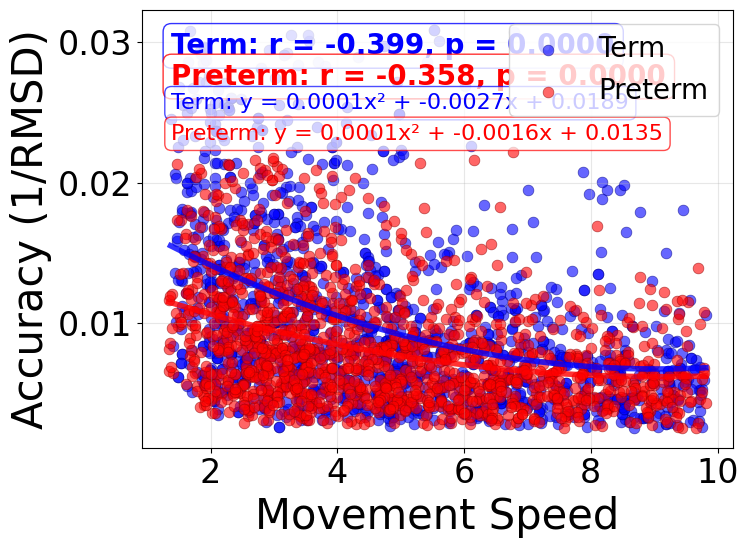

=== ENHANCED OUTLIER REMOVAL FOR E-E RATIO ANALYSIS ===
Original data shape: (8083, 40)

Preterm cohort - Original size: 1656
  accuracy: Removed 156 outliers
  exploration_exploitation_ratio: Removed 116 outliers
Preterm cohort - Final size: 1384

Term cohort - Original size: 6427
  accuracy: Removed 657 outliers
  exploration_exploitation_ratio: Removed 408 outliers
Term cohort - Final size: 5362

Final data shape: (6746, 40)


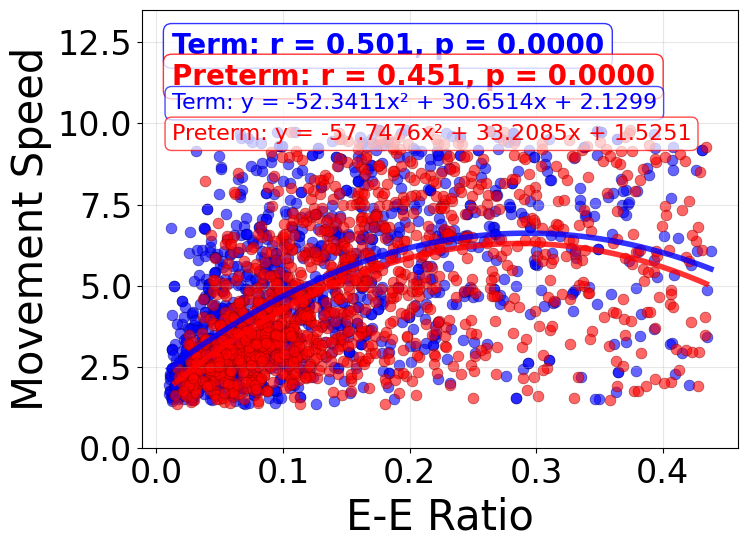

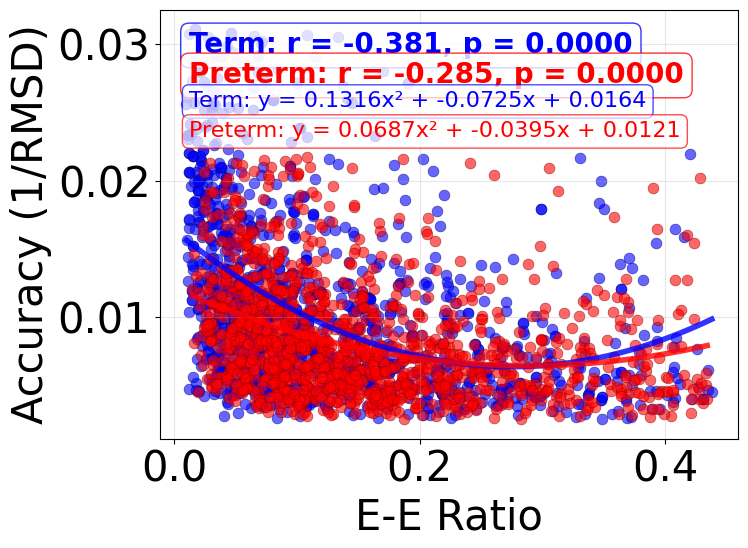


ANALYSIS COMPLETE
The enhanced analysis applies:
• IQR method (1.5 * IQR) for outlier detection
• Z-score method (threshold = 2.5) for extreme values
• Percentile-based removal (1st and 99th percentiles)
• Cohort-specific outlier removal
• Improved visualization with sample sizes


In [28]:
# Run the enhanced analysis with improved outlier removal
print("="*60)
print("RUNNING ENHANCED SPEED-ACCURACY TRADE-OFF ANALYSIS")
print("="*60)

# # Original analysis for comparison
# print("\n1. Original Analysis Results:")
# tradeoff_fig_original = analyze_speed_accuracy_tradeoff(merged_df)
# speed_fig_original, acc_fig_original = analyze_ratio_vs_performance(merged_df)

# print("\n" + "="*60)
# print("2. Enhanced Analysis with Improved Outlier Removal:")

# Enhanced analysis with better outlier removal
tradeoff_fig_enhanced = analyze_speed_accuracy_tradeoff_enhanced(merged_df)
speed_fig_enhanced, acc_fig_enhanced = analyze_ratio_vs_performance_enhanced(merged_df)

plt.show()

print("\n" + "="*60)
print("ANALYSIS COMPLETE")
print("="*60)
print("The enhanced analysis applies:")
print("• IQR method (1.5 * IQR) for outlier detection")
print("• Z-score method (threshold = 2.5) for extreme values")
print("• Percentile-based removal (1st and 99th percentiles)")
print("• Cohort-specific outlier removal")
print("• Improved visualization with sample sizes")
print("="*60)